In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# 1. 핵심 데이터셋 4개만 로드
customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

# 시간 데이터 datetime 변환
time_cols = ['order_purchase_timestamp', 'order_estimated_delivery_date', 'order_delivered_customer_date']
for col in time_cols:
    orders[col] = pd.to_datetime(orders[col])

In [ ]:
# 2. 데이터 병합 (Left Join)
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(payments, on='order_id', how='left')
df = df.merge(reviews, on='order_id', how='left')

# 3. 파생 변수 산출
# 배송 지연일수 (실제 - 예정, 지연 없으면 0)
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['delivery_delay'] = df['delivery_delay'].apply(lambda x: x if pd.notnull(x) and x > 0 else 0)

# 고객 단위 집계 (RFM 등)
reference_date = df['order_purchase_timestamp'].max()

master_df = df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum'),
    Payment_Installments=('payment_installments', 'mean'), # 평균 할부 개월 수
    Avg_Delivery_Delay=('delivery_delay', 'mean'),
    Avg_Review_Score=('review_score', 'mean'),
    Customer_State=('customer_state', 'first')
).reset_index()

# 4. 타겟(Target) 라벨링
# 180일 이상 구매가 없으면 이탈(1)
master_df['Churn'] = (master_df['Recency'] >= 180).astype(int)

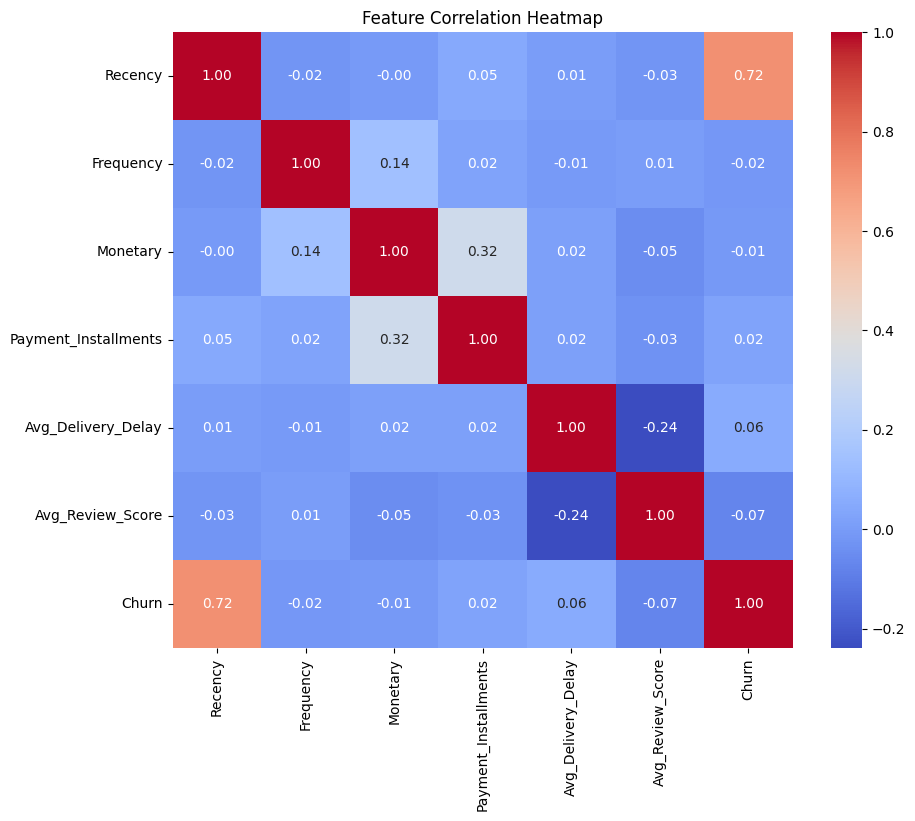

In [3]:
# 5. 상관관계 분석 (다중공선성 확인)
# 수치형 변수만 선택
numeric_cols = master_df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = master_df[numeric_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# 다중공선성 처리 로직

features_to_drop = ['Frequency', 'customer_unique_id', 'Recency'] # Recency는 Churn을 만든 기준이므로 제거
df_model = master_df.drop(columns=features_to_drop)

In [4]:
# 6. 범주형 변수 라벨 인코딩 및 저장 준비
encoders = {}
categorical_cols = ['Customer_State']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le  # 딕셔너리에 저장

# 전처리 객체(인코더) 저장
joblib.dump(encoders, 'data/olist_labelencoders.pkl')

# 7. 모델 학습 데이터 분리
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. XGBoost 모델 훈련
model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# 정확도 확인
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 9. 훈련된 모델 저장
joblib.dump(model, 'data/olist_xgboost_model.pkl')
print("인코더와 모델 저장 완료")

Model Accuracy: 71.20%
인코더와 모델 저장 완료


XGBoost 모델 성능 평가
Accuracy: 53.76%

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.63      0.44      5542
           1       0.77      0.50      0.61     13678

    accuracy                           0.54     19220
   macro avg       0.55      0.57      0.52     19220
weighted avg       0.65      0.54      0.56     19220



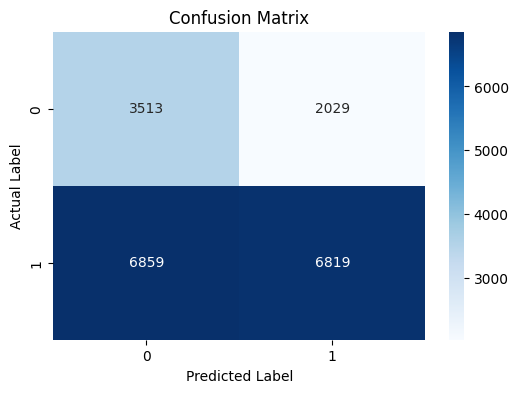

C:\Users\82108\AppData\Local\Temp\ipykernel_27156\2080018003.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')


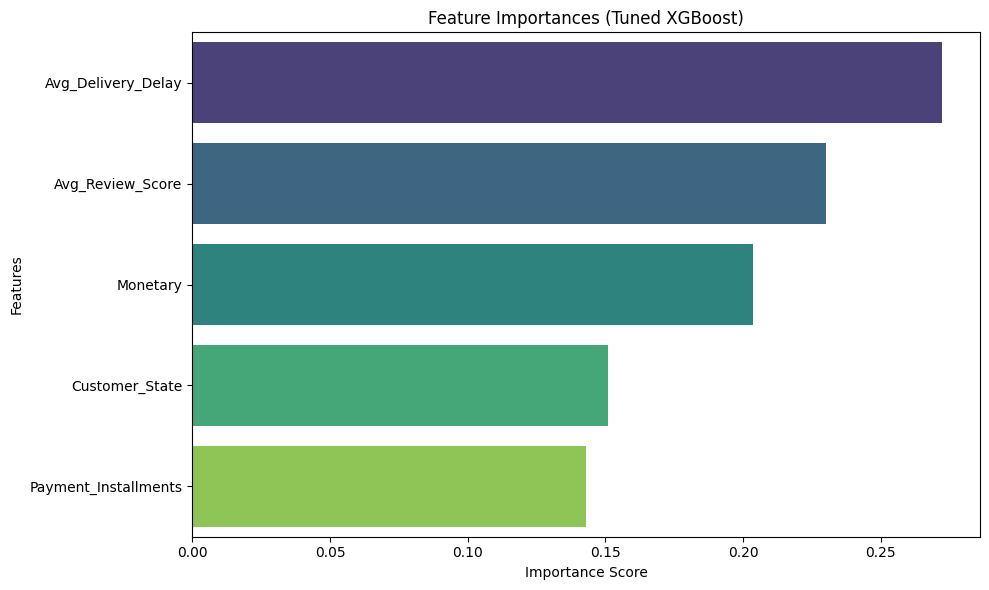

모델 저장 완료


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# 1. 데이터 준비 (이전 셀에서 만든 df_model 사용)
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 클래스 불균형 비율 계산
# 유지 고객(0) 수 / 이탈 고객(1) 수
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 3. XGBoost 하이퍼파라미터 튜닝 및 학습
xgb_tuned = XGBClassifier(
    n_estimators=200,          # 트리 개수 증가
    learning_rate=0.05,        # 학습률 감소 (안정적인 학습)
    max_depth=5,               # 트리의 최대 깊이 제한 (과적합 방지)
    subsample=0.8,             # 데이터의 80%만 사용하여 트리 생성 (일반화 성능 향상)
    colsample_bytree=0.8,      # 피처의 80%만 사용
    scale_pos_weight=ratio,    # 불균형 데이터 조정
    random_state=42
)

xgb_tuned.fit(X_train, y_train)

# 4. 예측 및 성능 평가
y_pred_tuned = xgb_tuned.predict(X_test)

print("XGBoost 모델 성능 평가")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

# 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. 피처 중요도(Feature Importances) 시각화
importances = xgb_tuned.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
sorted_features = X.columns[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')
plt.title("Feature Importances (Tuned XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

joblib.dump(xgb_tuned, 'data/olist_xgboost_model.pkl')
print("모델 저장 완료")

In [6]:
xgb_tuned = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.5, # 핵심: 이탈자(1)를 더 공격적으로 예측하도록 1.5배의 가중치 부여
    random_state=42
)

xgb_tuned.fit(X_train, y_train)
y_pred_tuned = xgb_tuned.predict(X_test)

print("XGBoost 모델 성능 평가 ===")
print(classification_report(y_test, y_pred_tuned))

joblib.dump(xgb_tuned, 'data/olist_xgboost_model.pkl')

XGBoost 모델 성능 평가 ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5542
           1       0.71      1.00      0.83     13678

    accuracy                           0.71     19220
   macro avg       0.36      0.50      0.42     19220
weighted avg       0.51      0.71      0.59     19220



c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


['data/olist_xgboost_model.pkl']

In [7]:
# 다수 클래스(1)와 소수 클래스(0)의 비율에 맞게 정상적인 가중치 적용
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1) # 약 0.4

xgb_final = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=ratio, # 비율 복구
    random_state=42
)

xgb_final.fit(X_train, y_train)

# 정상화된 모델 저장
joblib.dump(xgb_final, 'data/olist_xgboost_model.pkl')

['data/olist_xgboost_model.pkl']

베이스라인 모델 성능
Accuracy: 53.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.64      0.44      5542
           1       0.77      0.50      0.60     13678

    accuracy                           0.54     19220
   macro avg       0.55      0.57      0.52     19220
weighted avg       0.65      0.54      0.56     19220



C:\Users\82108\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82108\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82108\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\82108\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53448 (\N{HANGUL SYLLABLE TAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


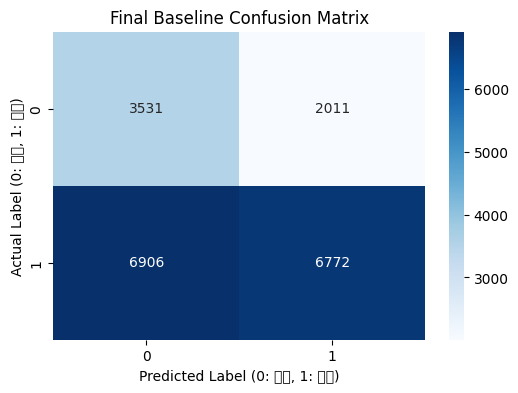

In [8]:
import joblib
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

loaded_model = joblib.load('data/olist_xgboost_model.pkl')

y_pred_final = loaded_model.predict(X_test)

print("베이스라인 모델 성능")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_final))

# 4. 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues')
plt.title("Final Baseline Confusion Matrix")
plt.ylabel('Actual Label (0: 유지, 1: 이탈)')
plt.xlabel('Predicted Label (0: 유지, 1: 이탈)')
plt.show()

In [9]:
items = pd.read_csv('data/olist_order_items_dataset.csv')

# 고객별 구매 상품 수량 및 평균 가격 산출
item_features = items.groupby('order_id').agg(
    total_items=('order_item_id', 'max'),
    avg_price=('price', 'mean')
).reset_index()

df = df.merge(item_features, on='order_id', how='left')
df['total_items'] = df['total_items'].fillna(0)
df['avg_price'] = df['avg_price'].fillna(0)

master_df = df.groupby('customer_unique_id').agg(
    Frequency=('order_id', 'nunique'),
    Monetary=('payment_value', 'sum'),
    Avg_Price=('avg_price', 'mean'),
    Total_Items=('total_items', 'sum'),
    Avg_Delivery_Delay=('delivery_delay', 'mean'),
    Avg_Review_Score=('review_score', 'mean'),
    Customer_State=('customer_state', 'first'),
    Recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days)
).reset_index()

master_df['Churn'] = (master_df['Recency'] >= 180).astype(int)
df_model_final = master_df.drop(columns=['customer_unique_id', 'Recency', 'Frequency']) # 다중공선성 변수 제거

In [11]:
from sklearn.metrics import precision_recall_curve

# 데이터 분리
X = pd.get_dummies(df_model_final.drop(columns=['Churn']), drop_first=True)
y = df_model_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_final = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_final.fit(X_train, y_train)

y_probs = xgb_final.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_final = (y_probs >= best_threshold).astype(int)

print(f"최적의 임계값: {best_threshold:.2f}")
print(f"개선된 Accuracy: {accuracy_score(y_test, y_pred_final) * 100:.2f}%")
print("\n[최종 Classification Report]")
print(classification_report(y_test, y_pred_final))

joblib.dump(xgb_final, 'data/olist_xgboost_model.pkl')
joblib.dump(best_threshold, 'data/best_threshold.pkl')

최적의 임계값: 0.51
개선된 Accuracy: 71.86%

[최종 Classification Report]
              precision    recall  f1-score   support

           0       0.81      0.03      0.06      5542
           1       0.72      1.00      0.83     13678

    accuracy                           0.72     19220
   macro avg       0.77      0.51      0.45     19220
weighted avg       0.75      0.72      0.61     19220



['data/best_threshold.pkl']